# Cluster deeply and perform quality control

In [2]:
import os
import sys
import glob
from pyhere import here
from pathlib import Path

import anndata
import numpy as np
import pandas as pd
import scanpy as sc
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
import seaborn as sns
import torch
import skmisc
import subprocess
from joblib import parallel_backend
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
import warnings

import zstandard as zstd
import hdf5plugin

import pickle

# My modules / functions
sys.path.append(str(here('scripts/misc')))  
import my_anndata as ma

## Parameters

In [3]:
# Saving
base_dir = str(here('data/integrate/first_pass/'))
file_dir = os.path.join(base_dir, 'files') 
plot_dir = os.path.join(base_dir, 'plot') 
tmp_dir = os.path.join(base_dir, 'tmp') 
emb_dir = os.path.join(base_dir, 'embedding') 
objects_dir = os.path.join(base_dir, 'objects') 

In [4]:
# Plotting
plt.style.use('default') 

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
 
SMALL_SIZE = 4
MEDIUM_SIZE = 6
BIGGER_SIZE = 8
 
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y ladata_fullels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick ladata_fullels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick ladata_fullels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

sc.set_figure_params(figsize=(2, 2), frameon=False, dpi_save= 300)

sc.settings.figdir = plot_dir
%config InlineBackend.print_figure_kwargs={'facecolor': 'w'}
%config InlineBackend.figure_format='retina'

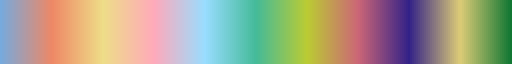

In [5]:
# Color bar
import tol_colors
import matplotlib.colors as mcolors

# Get the list of colors from each palette
light_colors = tol_colors.light[:7] # remove overlapping colors
bright_colors = tol_colors.muted[:4] # remove overlapping colors

# Combine the two lists of colors
combined_colors = light_colors + bright_colors

# Now, use this longer list to create a colormap or pass it directly to Scanpy
combined_cmap = mcolors.LinearSegmentedColormap.from_list(
    'combined_tol', combined_colors
)
combined_cmap

## Load

In [ ]:
adata = sc.read_h5ad(os.path.join(objects_dir, 'first_pass_1000_with_embeddings.h5ad'))
# Keep only scpoli_1000_technical_20_20 neighbors/embeddings
#adata.uns = {k: v for k, v in adata.uns.items() if k.startswit('scpoli_1000_technical_20_20_neighbors')}
adata.uns = {k: v for k, v in adata.uns.items() if k.startswith('scpoli_1000_technical_ic_id_donor_overall_20_20')}
adata.obsm = {k: v for k, v in adata.obsm.items() if k.startswith('scpoli_1000_technical_ic_id_donor_overall_20_20') or
              k.startswith('X_scpoli_1000_technical_ic_id_donor_overall_20_20')}
adata.obsp = {k: v for k, v in adata.obsp.items() if k.startswith('scpoli_1000_technical_ic_id_donor_overall_20_20')}

In [ ]:
# Full data object
adata_full=sc.read_h5ad(here("data/anndata/AB_combined.h5ad"))

## Add integration data to full adata object

In [ ]:
# Check all cells excist
np.all(adata_full.obs_names == adata.obs_names)

In [ ]:
# Do all hvg genes excist in the full anndata object
np.all(adata.var_names.isin(adata_full.var_names))  

In [ ]:
# add missing columns from obs
if hasattr(adata, 'obs') and adata.obs is not None:
    for col in adata.obs.columns:
        if col not in adata_full.obs.columns:
            adata_full.obs[col] = adata.obs[col]

In [ ]:
if hasattr(adata, 'obsm') and adata.obsm is not None:
    for key in adata.obsm.keys():
        if key not in adata_full.obsm:
            adata_full.obsm[key] = adata.obsm[key]

In [ ]:
if hasattr(adata, 'obsp') and adata.obsp is not None:
    for key in adata.obsp.keys():
        if key not in adata_full.obsp:
            adata_full.obsp[key] = adata.obsp[key]

In [ ]:
if hasattr(adata, 'uns') and adata.uns is not None:
    for key in adata.uns.keys():
        if key not in adata_full.uns:
            adata_full.uns[key] = adata.uns[key]

In [ ]:
sc.tl.leiden(adata_full, neighbors_key='scpoli_1000_technical_ic_id_donor_overall_20_20_neighbors', flavor="igraph", key_added='test')

## Cluster deeply

In [ ]:
sc.tl.leiden(adata_full, resolution=15, neighbors_key='scpoli_1000_technical_ic_id_donor_overall_20_20_neighbors', flavor="igraph", n_iterations=2, key_added='leiden_igraph_15')

## Plot

In [ ]:
sc.set_figure_params(figsize=(6,6), frameon=False, dpi_save= 300)

key = 'X_scpoli_1000_technical_ic_id_donor_overall_20_20_umap'
col = 'leiden_igraph_15'

n_cells = adata.shape[0]
marker_size = 110000 / n_cells

# Prepare DataFrame
df_umap = pd.DataFrame(adata_full.obsm[key], columns=['UMAP1','UMAP2'])
df_umap[col] = adata_full.obs[col].astype(str).values

# Create a palette mapping each category to a color
categories = df_umap[col].unique()
n_categories = len(categories)
palette = {cat: combined_cmap(i/(n_categories-1)) for i, cat in enumerate(categories)}

# Plot
fig = sns.scatterplot(
    data=df_umap, 
    x='UMAP1', y='UMAP2', 
    hue=col, 
    palette=palette, 
    s=marker_size 
)

fig.set_axis_off()
fig.set_title(col)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), 
           ncol=min(10, n_categories), fontsize=6, markerscale=6)

plt.show()

## Save

In [ ]:
# metadata to csv
adata_full.obs.to_csv(os.path.join(file_dir, 'integrate_winner.csv'), index_label='barcode')

In [ ]:
# temporary version of adata in first pass objects dir (we will save it in anndata file as AC_combined once we are finished with this QC)
adata_full.write(os.path.join(objects_dir, 'integrate_winner.h5ad')) 

In [ ]:
adata_full=sc.read_h5ad(os.path.join(objects_dir, 'integrate_winner.h5ad'))

In [ ]:
adata = sc.read_h5ad(os.path.join(objects_dir, 'first_pass_1000_with_embeddings.h5ad'))

In [ ]:
adata.obs['technical_donor'] = (adata.obs['library_prep'].astype(str) + "_" + adata.obs['ic_id_study_overall'].astype(str) + "_" + adata.obs['cell_nuclei'].astype(str) + adata.obs['ic_id_donor_overall'].astype(str))


In [11]:
adata = sc.read_h5ad(os.path.join(objects_dir, 'first_pass_1000_with_embeddings.h5ad'))

In [12]:
adata.obs['technical_donor'] = (adata.obs['library_prep'].astype(str) + "_" + adata.obs['ic_id_study_overall'].astype(str) + "_" + adata.obs['cell_nuclei'].astype(str) + adata.obs['ic_id_donor_overall'].astype(str))

In [ ]:
# Backup original connectivity if it exists
obsp_backup = adata.obsp.get('connectivities', None)

# Temporarily rename for iLISI
adata.uns['neighbors_backup'] = adata.uns['X_pca_neighbors']       # backup
adata.uns['neighbors'] = adata.uns['X_pca_neighbors']              # scIB sees this
adata.obsp['connectivities'] = adata.obsp['X_pca_neighbors_connectivities']

# Run iLISI
ilisi_scores = ilisi_graph(
    adata,
    batch_key='technical_donor',
    use_rep='X_pca',
    n_cores = 100,
    type_='batch'
)

# Restore original names
adata.uns['X_pca_neighbors'] = adata.uns.pop('neighbors')
adata.obsp.pop('connectivities')
if obsp_backup is not None:
    adata.obsp['connectivities'] = obsp_backup


In [15]:
import scanpy as sc
import numpy as np
import pandas as pd
from scipy.stats import entropy
from sklearn.metrics import silhouette_score

# ------------------------------
# Settings
# ------------------------------
batch_key = 'technical_donor'  # batch column
n_neighbors_entropy = 30        # neighbors for local entropy
n_per_batch = 1000              # number of cells per batch for stratified subsample
n_cores = 8                     # for iLISI

# ------------------------------
# Stratified subsampling
# ------------------------------
batch_labels_all = adata.obs[batch_key].values
subset_indices = []

for batch in np.unique(batch_labels_all):
    batch_idx = np.where(batch_labels_all == batch)[0]
    if len(batch_idx) <= n_per_batch:
        subset_indices.extend(batch_idx)
    else:
        subset_indices.extend(np.random.choice(batch_idx, n_per_batch, replace=False))

subset_indices = np.array(subset_indices)
adata_sub = adata[subset_indices].copy()
batch_labels = adata_sub.obs[batch_key].values
print(f"Subsampled {len(subset_indices)} cells across {len(np.unique(batch_labels))} batches.")

# ------------------------------
# Embeddings to evaluate
# ------------------------------
embedding_keys = [key for key in adata_sub.obsm.keys()
                  if (('donor' in key.lower()) or ('pca' in key.lower()))
                  and ('umap' not in key.lower())]

# Store results
results = {}

# ------------------------------
# Loop over embeddings
# ------------------------------
for emb_name in embedding_keys:
    print(f"\nProcessing embedding: {emb_name}")
    embedding = adata_sub.obsm[emb_name]

    # -----------------------
    # Ensure neighbors exist for entropy
    # -----------------------
    neighbors_key = f"{emb_name}_neighbors"
    if neighbors_key not in adata_sub.uns:
        print(f"Neighbors not found for {emb_name}, computing...")
        sc.pp.neighbors(adata_sub, use_rep=emb_name, n_neighbors=n_neighbors_entropy, key_added=neighbors_key)

    conn_key = f"{neighbors_key}_connectivities"
    if conn_key not in adata_sub.obsp:
        raise ValueError(f"Connectivity matrix {conn_key} not found in obsp for {emb_name}")

    conn = adata_sub.obsp[conn_key].tocsr()
    knn_indices = [row.indices[:n_neighbors_entropy] for row in conn]

    # -----------------------
    # 1) Local batch entropy
    # -----------------------
    try:
        entropies = []
        for neighbors in knn_indices:
            neighbor_batches = batch_labels[neighbors]
            unique_batches, inverse = np.unique(neighbor_batches, return_inverse=True)
            counts = np.bincount(inverse)
            probs = counts / counts.sum()
            entropies.append(entropy(probs))
        entropy_score = np.median(entropies)
    except Exception as e:
        print(f"Local entropy failed for {emb_name}: {e}")
        entropy_score = np.nan

    # -----------------------
    # 2) Batch silhouette
    # -----------------------
    try:
        sil_score = silhouette_score(embedding, batch_labels)
    except Exception as e:
        print(f"Batch silhouette failed for {emb_name}: {e}")
        sil_score = np.nan

    # -----------------------
    # Store results
    # -----------------------
    results[emb_name] = {
        'local_entropy_median': entropy_score,
        'batch_silhouette': sil_score
    }

# ------------------------------
# Convert to DataFrame
# ------------------------------
results_df = pd.DataFrame(results).T
print("\nUnsupervised batch correction metrics for embeddings:")
print(results_df)


Subsampled 173542 cells across 295 batches.

Processing embedding: X_pca

Processing embedding: scpoli_1000_technical_ic_id_donor_overall_20_20

Processing embedding: scvi_1000_technical_ic_id_donor_overall_20_20

Processing embedding: sysvi_1000_technical_ic_id_donor_overall_20_20

Unsupervised batch correction metrics for embeddings:
                                                 local_entropy_median  \
X_pca                                                        1.213008   
scpoli_1000_technical_ic_id_donor_overall_20_20              1.560710   
scvi_1000_technical_ic_id_donor_overall_20_20                1.264332   
sysvi_1000_technical_ic_id_donor_overall_20_20               1.560710   

                                                 batch_silhouette  
X_pca                                                   -0.229601  
scpoli_1000_technical_ic_id_donor_overall_20_20         -0.232924  
scvi_1000_technical_ic_id_donor_overall_20_20           -0.092029  
sysvi_1000_technical_ic_